Input: Dataset D, model θ, learning rate η,
       clipping norm C, noise σ, epochs E

For each epoch:
    For each batch B:

        1. Compute per-sample gradients:
           gi = ∇θ L(θ, xi)

        2. Clip gradients:
           gi ← gi / max(1, ||gi|| / C)

        3. Average gradients:
           g = (1 / |B|) Σ gi

        4. Add Gaussian noise:
           g̃ = g + N(0, σ²C²)

        5. Update model:
           θ ← θ - η * g̃

In [ ]:
# =========================================================
# DP-SGD
# =========================================================

import torch
import torch.nn as nn
from torchvision import datasets, transforms
import math
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# CONFIGURATION
# =========================================================
class Config:
    """
    Stores all hyperparameters

    C  = CLIP_NORM (gradient bound)
    σ  = NOISE_MULTIPLIER (noise level)
    δ  = DELTA (failure probability)
    """
    DATA_PATH = "./data"
    BATCH_SIZE = 32
    TEST_BATCH_SIZE = 64
    LEARNING_RATE = 0.05
    CLIP_NORM = 1.0
    NOISE_MULTIPLIER = 1.0
    EPOCHS = 5 
    DELTA = 1e-5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================================================
# MOMENTS ACCOUNTANT
# =========================================================
class MomentsAccountant:
    """
    Tracks privacy loss using Moments Accountant

    Formula (from paper):

    ε = min_λ ( α(λ) - log(δ) ) / λ

    where:
    α(λ) = log moment generating function

    Here we use approximation:
    α(λ) ≈ (q² * λ(λ+1)) / (2σ²)

    q = sampling rate = batch_size / dataset_size
    """

    def __init__(self, q, sigma, delta):
        self.q = q              # sampling probability
        self.sigma = sigma      # noise multiplier
        self.delta = delta      # failure probability
        self.steps = 0

        # Different λ values (important for tight bound)
        self.lambdas = list(range(1, 32))

        # Store accumulated log moments
        self.moments = {l: 0.0 for l in self.lambdas}

    def step(self):
        """
        Accumulate privacy loss per training step
        """
        self.steps += 1

        for l in self.lambdas:
            # α(λ) approximation for Gaussian mechanism
            self.moments[l] += (self.q**2 * l * (l+1)) / (2 * self.sigma**2)

    def get_epsilon(self):
        """
        Compute ε using:
        ε = (α - log δ) / λ
        """
        eps = []

        for l in self.lambdas:
            alpha = self.moments[l]
            eps.append((alpha - math.log(self.delta)) / l)

        return min(eps), self.delta


# =========================================================
# MODEL
# =========================================================
class DigitClassifier(nn.Module):
    """
    Simple Neural Network:

    Input → FC1 → ReLU → FC2 → Output
    """

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


# =========================================================
# TRAINER
# =========================================================
class DPSGDTrainer:

    def __init__(self, config, train_dataset, train_loader, test_loader):
        self.config = config
        self.train_dataset = train_dataset
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.criterion = nn.CrossEntropyLoss()

        # Sampling rate q = B/N
        self.q = config.BATCH_SIZE / len(train_dataset)

    def reset_accountant(self):
        self.accountant = MomentsAccountant(
            self.q,
            self.config.NOISE_MULTIPLIER,
            self.config.DELTA
        )

    # -----------------------------------------------------
    # EVALUATION
    # -----------------------------------------------------
    def evaluate(self, model):
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for data, target in self.test_loader:
                data, target = data.to(self.config.DEVICE), target.to(self.config.DEVICE)

                pred = model(data).argmax(dim=1)
                correct += (pred == target).sum().item()
                total += target.size(0)

        return 100 * correct / total


    # -----------------------------------------------------
    # PER-SAMPLE GRADIENTS
    # -----------------------------------------------------
    def compute_per_sample_gradients(self, model, data, target):
        """
        DP-SGD requirement:

        We compute:
            ∇L(x_i) for each sample
        """
        grads = []

        for i in range(len(data)):
            model.zero_grad(set_to_none=True)

            loss = self.criterion(
                model(data[i].unsqueeze(0)),
                target[i].unsqueeze(0)
            )
            loss.backward()

            grads.append([p.grad.detach().clone() for p in model.parameters()])

        return grads


    # -----------------------------------------------------
    # GRADIENT CLIPPING
    # -----------------------------------------------------
    def clip_gradients(self, gradients):
        """
        Formula:

        g ← g / max(1, ||g|| / C)

        Ensures:
        Sensitivity ≤ C
        """
        clipped = []

        for grad_list in gradients:
            norm = torch.sqrt(sum([g.norm()**2 for g in grad_list]))

            scale = min(1.0, self.config.CLIP_NORM / (norm + 1e-6))

            clipped.append([g * scale for g in grad_list])

        return clipped


    # -----------------------------------------------------
    # ADD NOISE
    # -----------------------------------------------------
    def add_noise(self, gradients):
        """
        DP-SGD Update:

        g̃ = (1/B) Σ g_i + N(0, σ²C²)

        Noise ensures privacy
        """
        batch_size = len(gradients)
        noisy = []

        for i in range(len(gradients[0])):
            stacked = torch.stack([g[i] for g in gradients])

            avg = torch.mean(stacked, dim=0)

            noise = torch.normal(
                0,
                self.config.NOISE_MULTIPLIER * self.config.CLIP_NORM,
                size=avg.shape,
                device=avg.device
            )

            noisy.append(avg + noise / batch_size)

        return noisy


    # -----------------------------------------------------
    # MODEL UPDATE
    # -----------------------------------------------------
    def update_model(self, model, grads):
        """
        Gradient Descent:

        θ ← θ - η * g̃
        """
        with torch.no_grad():
            for p, g in zip(model.parameters(), grads):
                p -= self.config.LEARNING_RATE * g


    # -----------------------------------------------------
    # BASELINE TRAINING (NO PRIVACY)
    # -----------------------------------------------------
    def train_baseline(self):
        model = DigitClassifier().to(self.config.DEVICE)
        optimizer = torch.optim.SGD(model.parameters(), lr=self.config.LEARNING_RATE)

        acc_history = []

        for epoch in range(self.config.EPOCHS):
            model.train()

            for data, target in self.train_loader:
                data, target = data.to(self.config.DEVICE), target.to(self.config.DEVICE)

                optimizer.zero_grad()
                loss = self.criterion(model(data), target)
                loss.backward()
                optimizer.step()

            acc = self.evaluate(model)
            acc_history.append(acc)

            print(f"[Baseline] Epoch {epoch+1} | Acc: {acc:.2f}%")

        return acc_history


    # -----------------------------------------------------
    # DP TRAINING
    # -----------------------------------------------------
    def train_dp(self):
        model = DigitClassifier().to(self.config.DEVICE)
        self.reset_accountant()

        acc_history = []
        eps_history = []

        for epoch in range(self.config.EPOCHS):
            model.train()

            for data, target in self.train_loader:
                data, target = data.to(self.config.DEVICE), target.to(self.config.DEVICE)

                grads = self.compute_per_sample_gradients(model, data, target)
                grads = self.clip_gradients(grads)
                grads = self.add_noise(grads)
                self.update_model(model, grads)

                # Update privacy accountant
                self.accountant.step()

            acc = self.evaluate(model)
            eps, _ = self.accountant.get_epsilon()

            acc_history.append(acc)
            eps_history.append(eps)

            print(f"[DP] Epoch {epoch+1} | Acc: {acc:.2f}% | ε: {eps:.4f}")

        return acc_history, eps_history
    # =========================================================
# EXPERIMENTS
# =========================================================
def experiment_noise(trainer):
    sigmas = [0.5, 1.0, 2.0, 4.0]
    acc = []

    for s in sigmas:
        trainer.config.NOISE_MULTIPLIER = s
        print(f"\nσ = {s}")
        a, _ = trainer.train_dp()
        acc.append(a[-1])

    return sigmas, acc


def experiment_clipping(trainer):
    clips = [0.5, 1.0, 2.0, 4.0]
    acc = []

    for c in clips:
        trainer.config.CLIP_NORM = c
        print(f"\nC = {c}")
        a, _ = trainer.train_dp()
        acc.append(a[-1])

    return clips, acc


# =========================================================
# PLOTTING
# =========================================================
def plot_all(baseline, dp_acc, dp_eps, sigmas, acc_noise, clips, acc_clip):

    plt.figure(figsize=(14,8))

    # Baseline vs DP
    plt.subplot(2,2,1)
    plt.plot(baseline, label="Baseline")
    plt.plot(dp_acc, label="DP")
    plt.title("Baseline vs DP")
    plt.legend()
    plt.grid()

    # Privacy
    plt.subplot(2,2,2)
    plt.plot(dp_eps, dp_acc, marker='o')
    plt.title("Privacy vs Accuracy")
    plt.grid()

    # Noise
    plt.subplot(2,2,3)
    plt.plot(sigmas, acc_noise, marker='o')
    plt.title("Noise vs Accuracy")
    plt.xlabel("σ")
    plt.grid()

    # Clipping
    plt.subplot(2,2,4)
    plt.plot(clips, acc_clip, marker='o')
    plt.title("Clipping vs Accuracy")
    plt.xlabel("C")
    plt.grid()

    plt.tight_layout()
    plt.show()


# =========================================================
# MAIN
# =========================================================
def main():

    config = Config()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST(config.DATA_PATH, train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(config.DATA_PATH, train=False, download=True, transform=transform)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=config.TEST_BATCH_SIZE, shuffle=False)

    trainer = DPSGDTrainer(config, train_dataset, train_loader, test_loader)

    baseline = trainer.train_baseline()
    dp_acc, dp_eps = trainer.train_dp()

    sigmas, acc_noise = experiment_noise(trainer)
    clips, acc_clip = experiment_clipping(trainer)

    plot_all(baseline, dp_acc, dp_eps, sigmas, acc_noise, clips, acc_clip)


if __name__ == "__main__":
    main()

[Baseline] Epoch 1 | Acc: 95.83%
[Baseline] Epoch 2 | Acc: 96.75%
[Baseline] Epoch 3 | Acc: 97.32%
[Baseline] Epoch 4 | Acc: 97.64%
[Baseline] Epoch 5 | Acc: 97.54%
[DP] Epoch 1 | Acc: 86.65% | ε: 0.3799
[DP] Epoch 2 | Acc: 87.64% | ε: 0.3885
[DP] Epoch 3 | Acc: 87.82% | ε: 0.3970
[DP] Epoch 4 | Acc: 87.84% | ε: 0.4055
[DP] Epoch 5 | Acc: 87.31% | ε: 0.4141

σ = 0.5
[DP] Epoch 1 | Acc: 88.75% | ε: 0.4055
[DP] Epoch 2 | Acc: 89.98% | ε: 0.4397
[DP] Epoch 3 | Acc: 90.58% | ε: 0.4738
[DP] Epoch 4 | Acc: 91.08% | ε: 0.5079
[DP] Epoch 5 | Acc: 91.03% | ε: 0.5421

σ = 1.0
[DP] Epoch 1 | Acc: 86.92% | ε: 0.3799
[DP] Epoch 2 | Acc: 87.87% | ε: 0.3885
[DP] Epoch 3 | Acc: 88.38% | ε: 0.3970
[DP] Epoch 4 | Acc: 88.19% | ε: 0.4055
[DP] Epoch 5 | Acc: 87.69% | ε: 0.4141

σ = 2.0
[DP] Epoch 1 | Acc: 79.00% | ε: 0.3735
[DP] Epoch 2 | Acc: 79.14% | ε: 0.3757
[DP] Epoch 3 | Acc: 76.98% | ε: 0.3778
[DP] Epoch 4 | Acc: 77.88% | ε: 0.3799
[DP] Epoch 5 | Acc: 79.00% | ε: 0.3821

σ = 4.0
[DP] Epoch 1 | Acc:

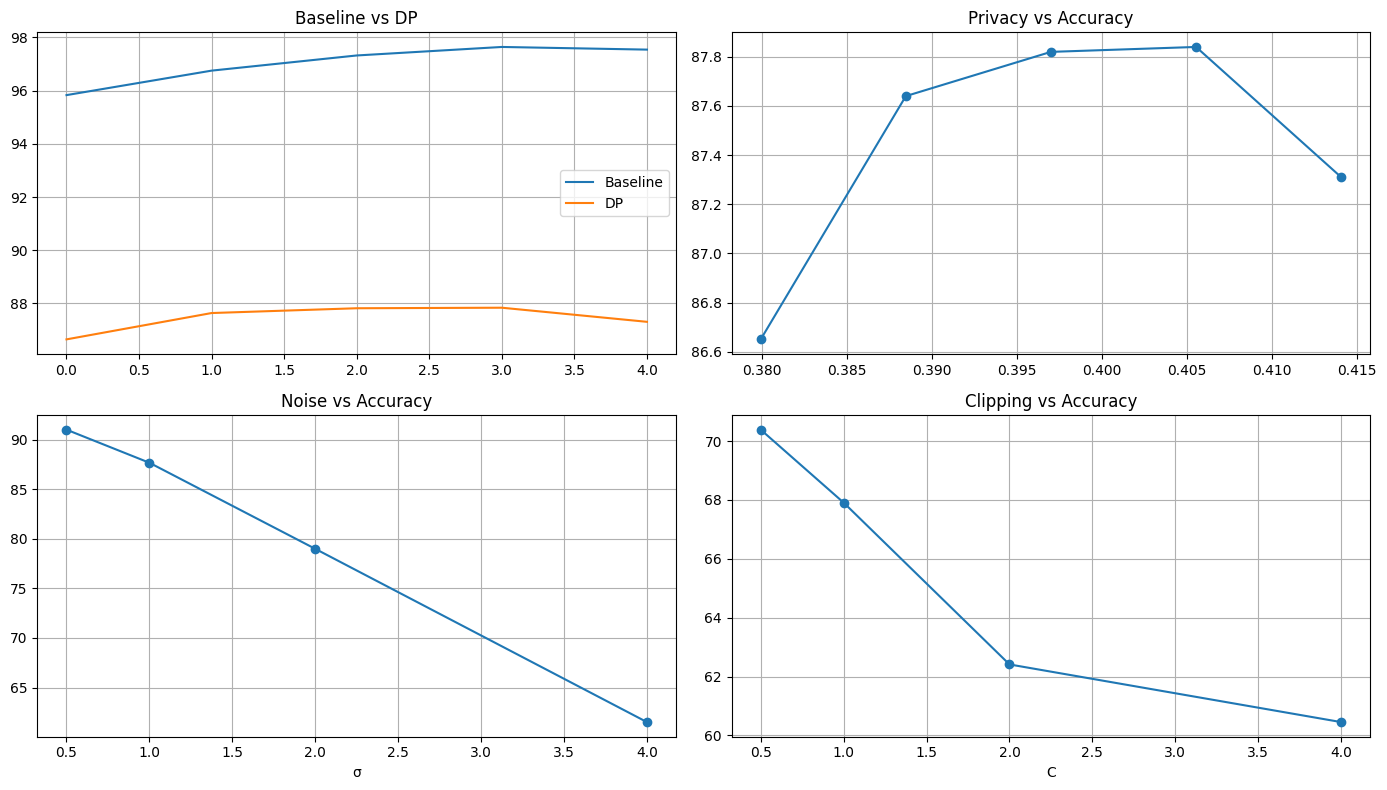

In [2]:
# =========================================================
# DP-SGD
# =========================================================

import torch
import torch.nn as nn
from torchvision import datasets, transforms
import math
import numpy as np
import matplotlib.pyplot as plt


# =========================================================
# CONFIG
# =========================================================
class Config:
    DATA_PATH = "./data"
    BATCH_SIZE = 32
    TEST_BATCH_SIZE = 64
    LEARNING_RATE = 0.05
    CLIP_NORM = 1.0
    NOISE_MULTIPLIER = 1.0
    EPOCHS = 5 
    DELTA = 1e-5
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================================================
# MOMENTS ACCOUNTANT
# =========================================================
class MomentsAccountant:

    def __init__(self, q, sigma, delta):
        self.q = q
        self.sigma = sigma
        self.delta = delta
        self.steps = 0
        self.lambdas = list(range(1, 32))
        self.moments = {l: 0.0 for l in self.lambdas}

    def step(self):
        self.steps += 1
        for l in self.lambdas:
            self.moments[l] += (self.q**2 * l * (l+1)) / (2 * self.sigma**2)

    def get_epsilon(self):
        eps = []
        for l in self.lambdas:
            alpha = self.moments[l]
            eps.append((alpha - math.log(self.delta)) / l)
        return min(eps), self.delta


# =========================================================
# MODEL
# =========================================================
class DigitClassifier(nn.Module):

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = x.view(-1, 28*28)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


# =========================================================
# TRAINER
# =========================================================
class DPSGDTrainer:

    def __init__(self, config, train_dataset, train_loader, test_loader):
        self.config = config
        self.train_dataset = train_dataset
        self.train_loader = train_loader
        self.test_loader = test_loader
        self.criterion = nn.CrossEntropyLoss()

        self.q = config.BATCH_SIZE / len(train_dataset)

    def reset_accountant(self):
        self.accountant = MomentsAccountant(
            self.q,
            self.config.NOISE_MULTIPLIER,
            self.config.DELTA
        )

    def evaluate(self, model):
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for data, target in self.test_loader:
                data, target = data.to(self.config.DEVICE), target.to(self.config.DEVICE)
                pred = model(data).argmax(dim=1)
                correct += (pred == target).sum().item()
                total += target.size(0)

        return 100 * correct / total

    def compute_per_sample_gradients(self, model, data, target):
        grads = []
        for i in range(len(data)):
            model.zero_grad(set_to_none=True)
            loss = self.criterion(model(data[i].unsqueeze(0)), target[i].unsqueeze(0))
            loss.backward()
            grads.append([p.grad.detach().clone() for p in model.parameters()])
        return grads

    def clip_gradients(self, gradients):
        clipped = []
        for grad_list in gradients:
            norm = torch.sqrt(sum([g.norm()**2 for g in grad_list]))
            scale = min(1.0, self.config.CLIP_NORM / (norm + 1e-6))
            clipped.append([g * scale for g in grad_list])
        return clipped

    def add_noise(self, gradients):
        batch_size = len(gradients)
        noisy = []

        for i in range(len(gradients[0])):
            stacked = torch.stack([g[i] for g in gradients])
            avg = torch.mean(stacked, dim=0)

            noise = torch.normal(
                0,
                self.config.NOISE_MULTIPLIER * self.config.CLIP_NORM,
                size=avg.shape,
                device=avg.device
            )

            noisy.append(avg + noise / batch_size)

        return noisy

    def update_model(self, model, grads):
        with torch.no_grad():
            for p, g in zip(model.parameters(), grads):
                p -= self.config.LEARNING_RATE * g

    # ---------------- BASELINE ----------------
    def train_baseline(self):
        model = DigitClassifier().to(self.config.DEVICE)
        optimizer = torch.optim.SGD(model.parameters(), lr=self.config.LEARNING_RATE)

        acc_history = []

        for epoch in range(self.config.EPOCHS):
            model.train()

            for data, target in self.train_loader:
                data, target = data.to(self.config.DEVICE), target.to(self.config.DEVICE)

                optimizer.zero_grad()
                loss = self.criterion(model(data), target)
                loss.backward()
                optimizer.step()

            acc = self.evaluate(model)
            acc_history.append(acc)
            print(f"[Baseline] Epoch {epoch+1} | Acc: {acc:.2f}%")

        return acc_history

    # ---------------- DP TRAIN ----------------
    def train_dp(self):
        model = DigitClassifier().to(self.config.DEVICE)
        self.reset_accountant()

        acc_history = []
        eps_history = []

        for epoch in range(self.config.EPOCHS):
            model.train()

            for data, target in self.train_loader:
                data, target = data.to(self.config.DEVICE), target.to(self.config.DEVICE)

                grads = self.compute_per_sample_gradients(model, data, target)
                grads = self.clip_gradients(grads)
                grads = self.add_noise(grads)
                self.update_model(model, grads)

                self.accountant.step()

            acc = self.evaluate(model)
            eps, _ = self.accountant.get_epsilon()

            acc_history.append(acc)
            eps_history.append(eps)

            print(f"[DP] Epoch {epoch+1} | Acc: {acc:.2f}% | ε: {eps:.4f}")

        return acc_history, eps_history


# =========================================================
# EXPERIMENTS
# =========================================================
def experiment_noise(trainer):
    sigmas = [0.5, 1.0, 2.0, 4.0]
    acc = []

    for s in sigmas:
        trainer.config.NOISE_MULTIPLIER = s
        print(f"\nσ = {s}")
        a, _ = trainer.train_dp()
        acc.append(a[-1])

    return sigmas, acc


def experiment_clipping(trainer):
    clips = [0.5, 1.0, 2.0, 4.0]
    acc = []

    for c in clips:
        trainer.config.CLIP_NORM = c
        print(f"\nC = {c}")
        a, _ = trainer.train_dp()
        acc.append(a[-1])

    return clips, acc


# =========================================================
# PLOTTING
# =========================================================
def plot_all(baseline, dp_acc, dp_eps, sigmas, acc_noise, clips, acc_clip):

    plt.figure(figsize=(14,8))

    # Baseline vs DP
    plt.subplot(2,2,1)
    plt.plot(baseline, label="Baseline")
    plt.plot(dp_acc, label="DP")
    plt.title("Baseline vs DP")
    plt.legend()
    plt.grid()

    # Privacy
    plt.subplot(2,2,2)
    plt.plot(dp_eps, dp_acc, marker='o')
    plt.title("Privacy vs Accuracy")
    plt.grid()

    # Noise
    plt.subplot(2,2,3)
    plt.plot(sigmas, acc_noise, marker='o')
    plt.title("Noise vs Accuracy")
    plt.xlabel("σ")
    plt.grid()

    # Clipping
    plt.subplot(2,2,4)
    plt.plot(clips, acc_clip, marker='o')
    plt.title("Clipping vs Accuracy")
    plt.xlabel("C")
    plt.grid()

    plt.tight_layout()
    plt.show()


# =========================================================
# MAIN
# =========================================================
def main():

    config = Config()

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    train_dataset = datasets.MNIST(config.DATA_PATH, train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(config.DATA_PATH, train=False, download=True, transform=transform)

    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=config.TEST_BATCH_SIZE, shuffle=False)

    trainer = DPSGDTrainer(config, train_dataset, train_loader, test_loader)

    baseline = trainer.train_baseline()
    dp_acc, dp_eps = trainer.train_dp()

    sigmas, acc_noise = experiment_noise(trainer)
    clips, acc_clip = experiment_clipping(trainer)

    plot_all(baseline, dp_acc, dp_eps, sigmas, acc_noise, clips, acc_clip)


if __name__ == "__main__":
    main()